# Load modules (code)

In [19]:
#import libraries
import numpy as np
import pandas as pd

#for visualisation
import seaborn as sns
import matplotlib.pyplot as plt

#our dataset
from sklearn.datasets import fetch_openml

#for dimensionality reduction
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

#selecting our models/pipelines
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

#classification methods
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Libraries for evaluation metrics
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load data (code)

In [16]:
# fetch dataset from openml by dataset id
dataset = fetch_openml(data_id=4538, as_frame=False) # 'as_frame' = False returns data and target as NumPy arrays

# extracting features and target labels
X = dataset.data     # features
y = dataset.target   # target labels
feature_names = dataset.feature_names # feature names
target_names = dataset.target_names

class_names = np.unique(y) # names of target classes
n_classes = len(class_names)

print("--- Dataset Info ---")
print("Total samples: ", X.shape[0])
print("Total features: ", X.shape[1])
print("Dataset shape: ", X.shape)
print("Feature names: ", feature_names)
print("Target name: ", target_names)
print("Target classes: ", class_names)
print("Number of classes: ", n_classes)

class_names, counts = np.unique(y, return_counts=True)
print("Class Value counts: ")
for cla, count in zip(class_names, counts): # determines target class value count to investigate class imbalance
    print(f"{cla}: {count}")

# check for missing values
print("Missing values: ", np.isnan(X).sum())

--- Dataset Info ---
Total samples:  9873
Total features:  32
Dataset shape:  (9873, 32)
Feature names:  ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32']
Target name:  ['Phase']
Target classes:  ['D' 'H' 'P' 'R' 'S']
Number of classes:  5
Class Value counts: 
D: 2741
H: 998
P: 2097
R: 1087
S: 2950
Missing values:  0


In [17]:
# perform a train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
    ) # Utilising a 70/30 split

print("Training set: ", X_train.shape[0], "samples")
print("Test set: ", X_test.shape[0], "samples")

Training set:  6911 samples
Test set:  2962 samples


Perform a singular train/test split to maintain consistent test sets across methods trained. Prevents data leakage issues

# Classification

## Classification methods

The classification methods applied are outlined below. Methods not discussed in class have been accurately sourced


1.   Gradient Booster Classifier (source: Scikit-Learn documentation)
2.   Random Forest
3.   Logistic Regression
4. Support Vector Classification (Non Linear SVC)



## Training (code)

---
### 1. Gradient Booster Classifier

In [18]:
# Build the model and perform hyperparameter tuning

# build baseline model
gb=GradientBoostingClassifier(random_state=42)

# grid to tune hyperparameters
param_grid_gb = {
    'n_estimators': [100, 200],  # describes the number of trees
    'learning_rate': [0.05, 0.1], # step size
    'max_depth': [2,3] # tree depth
}

# build grid
grid_gb=GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1
)

#fit model
grid_gb.fit(X_train, y_train)

# identify best parameters
print('Best parameters: ', grid_gb.best_params_)
print('Best CV Balanced Accuracy: ', grid_gb.best_score_)

# determining the top 3 parameter combinations
results_gb = pd.DataFrame(grid_gb.cv_results_)[['params','mean_test_score','std_test_score']]

# Fit the best model built from the hyperparameter grid
best_gb = grid_gb.best_estimator_
print('Best model from GridSearchCV: ', best_gb)

# make predictions and evaluate on test dataset and store probabilities
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test) # necessary to determine ROC/AUC curves

Best parameters:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV Balanced Accuracy:  0.5199706260940297
Best model from GridSearchCV:  GradientBoostingClassifier(n_estimators=200, random_state=42)


In [20]:
# Top 3 parameter combinations from grid search
results_df = pd.DataFrame(grid_gb.cv_results_)[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head(3).reset_index()
print("Top 3 Parameter Combinations (CV Balanced Accuracy):")
print(results_df.to_string(index=False))

Top 3 Parameter Combinations (CV Balanced Accuracy):
 index                                                       params  mean_test_score  std_test_score
     7  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}         0.519971        0.011952
     6  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}         0.499536        0.011646
     3 {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}         0.499045        0.009368


In [21]:
# derive model accuracy using a classification report
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.6097231600270088
              precision    recall  f1-score   support

           D       0.65      0.83      0.73       822
           H       0.54      0.37      0.44       300
           P       0.58      0.48      0.53       629
           R       0.56      0.40      0.46       326
           S       0.61      0.65      0.63       885

    accuracy                           0.61      2962
   macro avg       0.59      0.55      0.56      2962
weighted avg       0.60      0.61      0.60      2962



---
### 2. KNN Classifier

In [22]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [23]:
param_grid_knn = {
    "knn__n_neighbors": [3,5,7,9,11,13,15],
    "knn__weights": ["uniform","distance"],
    "knn__metric": ["euclidean","manhattan"]
}

In [24]:
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

print("Best model from GridSearchCV:", best_knn)
print("Best parameters:", grid_knn.best_params_)
print("Best CV Balanced Accuracy:", grid_knn.best_score_)

results_df_knn = pd.DataFrame(grid_knn.cv_results_)[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head(3).reset_index(drop=True)

print("Top 3 parameter Combinations (CV Balanced Accuracy) : ")
print(results_df_knn.to_string(index=False))

Best model from GridSearchCV: Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=3,
                                      weights='distance'))])
Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV Balanced Accuracy: 0.5815322039779385
Top 3 parameter Combinations (CV Balanced Accuracy) : 
                                                                         params  mean_test_score  std_test_score
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}         0.581532        0.017051
{'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}         0.561680        0.014933
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}         0.544816        0.006971


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.5072889  0.54481637 0.49825134 0.52659626 0.48064298 0.51118299
 0.47728901 0.50346666 0.46749113 0.49810815 0.46129968 0.49110328
 0.45734481 0.48356072        nan 0.5815322         nan 0.56168022
        nan 0.54274463        nan 0.53824649        nan 0.52657254
        nan 0.51867927        nan 0.51067644]
  warnings.warn(


In [25]:
# predictions
y_pred_knn = best_knn.predict(X_test)
y_proba_knn = best_knn.predict_proba(X_test)

print("Classification Report: KNN")
print(classification_report(y_test, y_pred_knn))

Classification Report: KNN
              precision    recall  f1-score   support

           D       0.66      0.82      0.73       822
           H       0.61      0.56      0.58       300
           P       0.62      0.52      0.56       629
           R       0.61      0.50      0.55       326
           S       0.70      0.68      0.69       885

    accuracy                           0.65      2962
   macro avg       0.64      0.61      0.62      2962
weighted avg       0.65      0.65      0.65      2962



---
### 3. Random Forest Classifier

In [26]:
rf = RandomForestClassifier(random_state=42)

parameter_grid = {
    'n_estimators': [100,200],
    'max_depth':[None,20],
    'max_features': ['sqrt','log2'],
    'min_samples_split': [2,5]
}
grid = GridSearchCV(rf,parameter_grid, cv=5, scoring='balanced_accuracy',n_jobs = -1)

grid.fit(X_train,y_train)

best_rf = grid.best_estimator_
print('Best model from GridSearchCV: ', best_rf)

print("Best Parameters:", grid.best_params_)
print('Best CV Balanced Accuracy: ', grid.best_score_)

# Top 3 parameter combinations from grid search
results_df = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head(3).reset_index(drop=True)
print("Top 3 Parameter Combinations (CV Balanced Accuracy):")
print(results_df.to_string(index=False))

# predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)

Best model from GridSearchCV:  RandomForestClassifier(n_estimators=200, random_state=42)
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Balanced Accuracy:  0.5643027539316536
Top 3 Parameter Combinations (CV Balanced Accuracy):
                                                                                  params  mean_test_score  std_test_score
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}         0.564303        0.010834
{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}         0.564303        0.010834
  {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}         0.562189        0.010830


In [27]:
print("Classification Report: Random Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=best_rf.classes_
))

Classification Report: Random Forest
              precision    recall  f1-score   support

           D       0.68      0.88      0.77       822
           H       0.85      0.39      0.53       300
           P       0.67      0.49      0.57       629
           R       0.69      0.42      0.52       326
           S       0.63      0.78      0.70       885

    accuracy                           0.67      2962
   macro avg       0.70      0.59      0.62      2962
weighted avg       0.68      0.67      0.65      2962



---
### 4. SVM

In [28]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'svm__C'      : [0.1, 1, 10],
    'svm__kernel' : ['rbf', 'linear'],
    'svm__gamma'  : ['scale', 'auto']
}

In [29]:
grid_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Linear SVM - Best parameters:", grid_svm.best_params_)
print("Linear SVM - Best CV Balanced Accuracy:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
print('Best model from GridSearchCV: ', best_svm)

# Top 3 parameter combinations from grid search
results_svm = pd.DataFrame(grid_svm.cv_results_)[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head(3).reset_index(drop=True)
print("Top 3 Parameter Combinations (CV Balanced Accuracy):")
print(results_svm.to_string(index=False))

Linear SVM - Best parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Linear SVM - Best CV Balanced Accuracy: 0.46350844907842664
Best model from GridSearchCV:  Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, probability=True, random_state=42))])
Top 3 Parameter Combinations (CV Balanced Accuracy):
                                                     params  mean_test_score  std_test_score
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.463508        0.009920
 {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}         0.463508        0.009920
  {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}         0.415642        0.008871


In [31]:
# predictions
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)

---
## Evaluation


Classification methods are evaluated using the following metrics:
1. Balanced Accuracy
2. The macro-average and micro-average of the One-vs-Rest ROC AUC score
3. Drawing the macro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.
4. Drawing the micro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.
5. For each class, drawing the One-vs-Rest ROCs for all classification methods into a separate graph, to allow for easy comparison between methods.
6. Drawing all relevant confusion matrices


### i. Balanced Accuracy


In [32]:
# Balanced accuracy evaluation
balanced_acc_aggr= {
    "Gradient Boosting": balanced_accuracy_score(y_test, y_pred_gb),
    "Random Forest": balanced_accuracy_score(y_test, y_pred_rf),
    "SVM": balanced_accuracy_score(y_test, y_pred_svm),
    "KNN": balanced_accuracy_score(y_test, y_pred_knn)
}

#Rank accuracies
df_accuracy = (pd.DataFrame
           .from_dict(balanced_acc_aggr, orient='index', columns=['Balanced Accuracy'])
           .sort_values('Balanced Accuracy', ascending=False)
           .round(4))

print(df_accuracy)

                   Balanced Accuracy
KNN                           0.6148
Random Forest                 0.5939
Gradient Boosting             0.5471
SVM                           0.4693


### ii. The macro-average and micro-average of the One-vs-Rest ROC AUC score

In [34]:
# convert labels to a binary format
classes = class_names
y_test_bin = label_binarize(y_test, classes=classes)

# need to standardize method outputs for probability
y_proba_gb = best_gb.predict_proba(X_test)
y_prob_rf = best_rf.predict_proba(X_test)
y_proba_svm = best_svm.predict_proba(X_test)
y_proba_knn = best_knn.predict_proba(X_test)

model_probs = {
    "Gradient Boosting": y_proba_gb,
    "Random Forest": y_prob_rf,
    "SVM": y_proba_svm,
    "KNN": y_proba_knn
}

We binarize the test data since roc applies only to datasets with binary classes. Without binarization, we cannot determine the true positive and false positive rates for our dataset which has 5 target classes

In [35]:
roc_results = {}

for model_name, y_proba in model_probs.items():
    macro = roc_auc_score(y_test_bin, y_proba, average='macro') # Evaluate ROC-AUC using macro average
    micro = roc_auc_score(y_test_bin, y_proba, average='micro') # Evaluate ROC-AUC using micro average
    roc_results[model_name] = {'Macro AUC': round(macro, 4),
                                'Micro AUC': round(micro, 4)}

roc_df = pd.DataFrame(roc_results).T
print("  ROC AUC Scores: Macro & Micro (One-vs-Rest)")
print(roc_df.to_string())


  ROC AUC Scores: Macro & Micro (One-vs-Rest)
                   Macro AUC  Micro AUC
Gradient Boosting     0.8535     0.8714
Random Forest         0.8941     0.9031
SVM                   0.8086     0.8334
KNN                   0.8469     0.8610


### iii. Plot the Macro-average ROC curve (aggregates all methods into one graph)


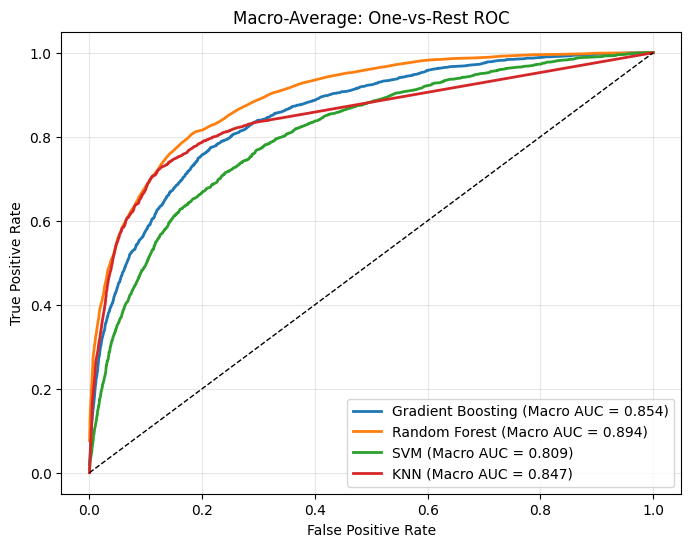

In [36]:
plt.figure(figsize=(8,6))

for model_name, y_proba in model_probs.items():
  # computing the ROC for each target class
  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

  # compute macro average ROC curve
  # Aggregate all FPR values

  all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

  # Interpolate all ROC curves at these points
  mean_tpr = np.zeros_like(all_fpr)

  for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

  # Average it
  mean_tpr /= n_classes

  # Compute macro AUC
  macro_auc = auc(all_fpr, mean_tpr)

  plt.plot(
      all_fpr,
      mean_tpr,
      label=f"{model_name} (Macro AUC = {macro_auc:.3f})",
      linewidth=2
)

plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average: One-vs-Rest ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### iv. Plot the micro-average ROC curve (aggregates all methods into one graph)

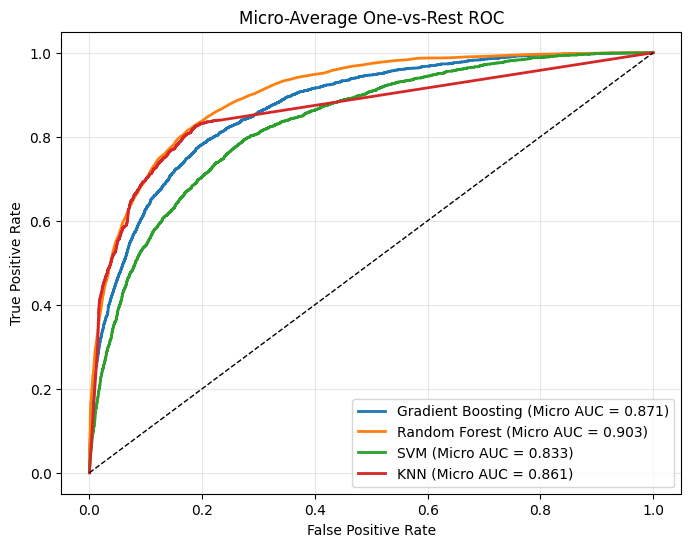

In [37]:
plt.figure(figsize=(8,6))

for model_name, y_proba in model_probs.items():

    # Compute ROC curve points (needed for plotting)
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_bin.ravel(),
        y_proba.ravel()
    )

    # Retrieve previously computed Micro AUC
    roc_auc_micro = roc_results[model_name]['Micro AUC']

    # Plot micro-average ROC curve
    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"{model_name} (Micro AUC = {roc_auc_micro:.3f})",
        linewidth=2
    )

plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average One-vs-Rest ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### v. For each class, drawing the One-vs-Rest ROCs for all methods into a separate graph, to allow for easy comparison between methods

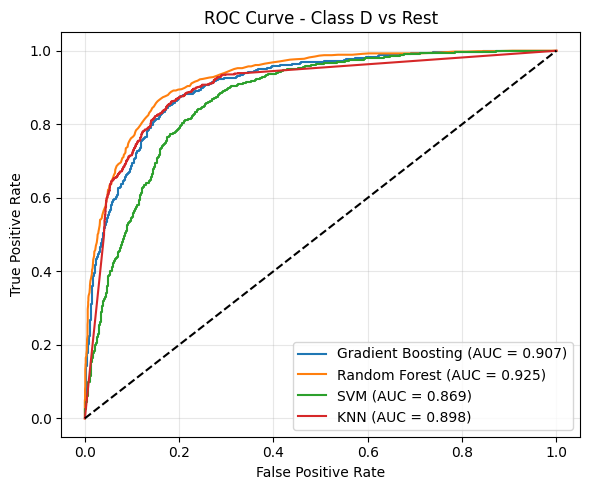

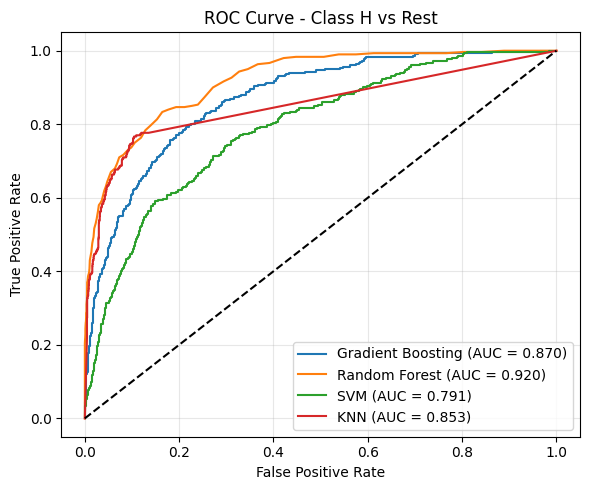

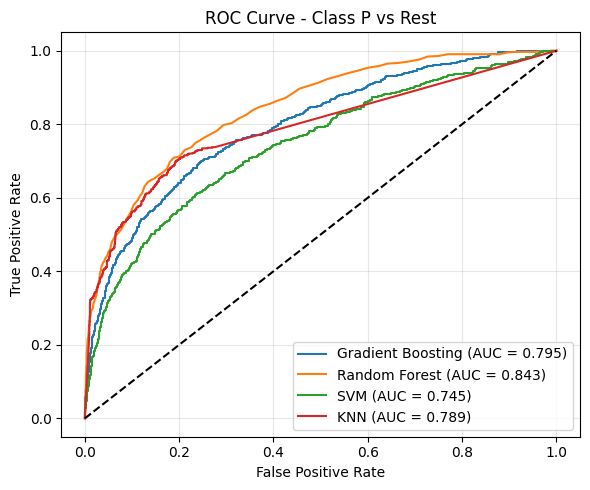

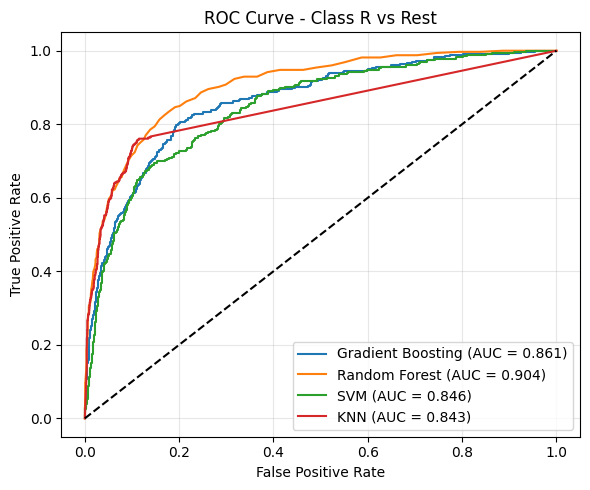

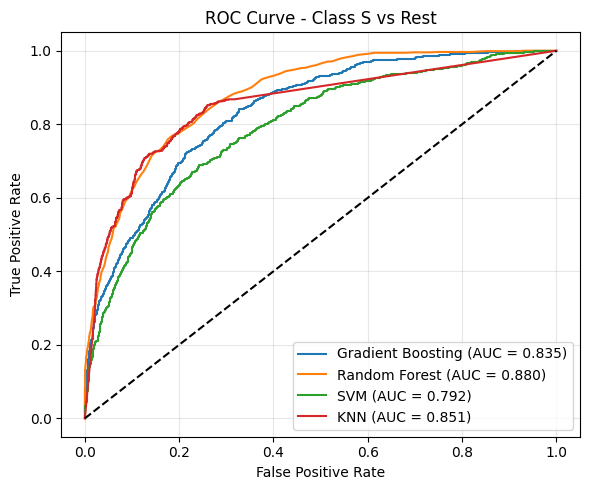

In [38]:
for i, class_name in enumerate(classes):

  plt.figure(figsize=(6,5))

  # loop through methods
  for model_name, y_proba in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

  plt.plot([0,1], [0,1], 'k--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title(f"ROC Curve - Class {class_name} vs Rest")

  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

## vi. Drawing all relevant confusion matrices

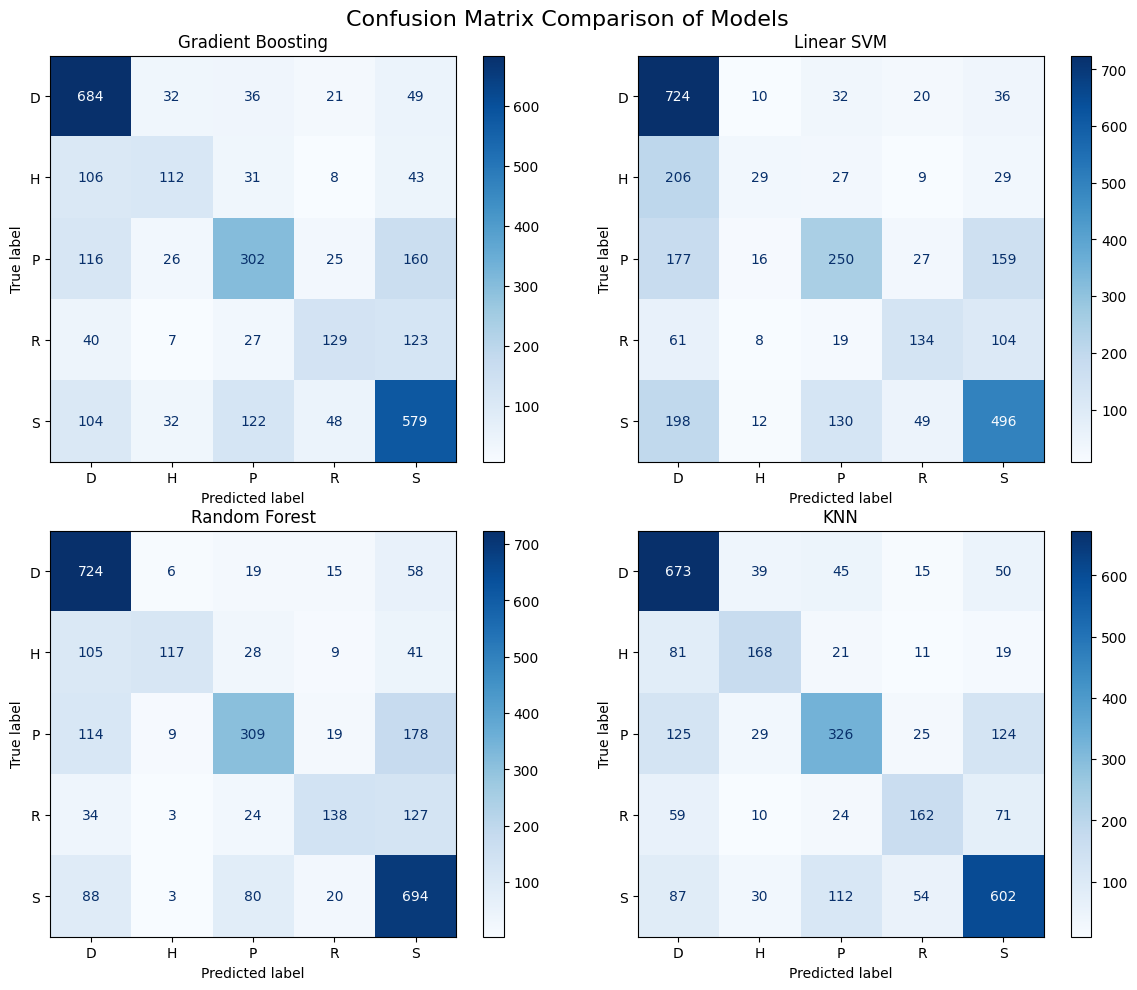

In [39]:
# compute confusion matrix
classes = np.unique(y_test)

# Predictions for each model
y_pred_gb = best_gb.predict(X_test)     # Gradient Boosting
y_pred_svm = best_svm.predict(X_test)   # SVM
y_pred_rf = best_rf.predict(X_test)     # Random Forest
y_pred_knn = best_knn.predict(X_test)   # KNN

# Compute confusion matrices
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=classes)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classes)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=classes)

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Gradient Boosting
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=classes)
disp_gb.plot(ax=axes[0,0], cmap="Blues", values_format="d")
axes[0,0].set_title("Gradient Boosting")

# SVM
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=classes)
disp_svm.plot(ax=axes[0,1], cmap="Blues", values_format="d")
axes[0,1].set_title("Linear SVM")

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=classes)
disp_rf.plot(ax=axes[1,0], cmap="Blues", values_format="d")
axes[1,0].set_title("Random Forest")

# KNN
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=classes)
disp_knn.plot(ax=axes[1,1], cmap="Blues", values_format="d")
axes[1,1].set_title("KNN")
fig.suptitle("Confusion Matrix Comparison of Models", fontsize=16)
plt.tight_layout()
plt.show()


---
# Build, fit and evaluate methods using the Dimensionality Reduction (PCA)

----
### 1. Random Forest - applying PCA

In [40]:
# training the pcs + random forest

rf_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=42)),
    ('rf',     RandomForestClassifier(random_state=42))
])

parameter_grid_rf_pca = {
    'rf__n_estimators': [100,200],
    'rf__max_depth':[None,20],
    'rf__max_features': ['sqrt','log2'],
    'rf__min_samples_split': [2,5]
}
grid_rf_pca = GridSearchCV(rf_pca_pipe,parameter_grid_rf_pca, cv=5, scoring='balanced_accuracy',n_jobs = -1)

grid_rf_pca.fit(X_train, y_train)

best_rf_pca = grid_rf_pca.best_estimator_
print("Best Parameters:", grid_rf_pca.best_params_)

Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


In [41]:
# testing the random forest pca
y_pred_rf_pca  = best_rf_pca.predict(X_test)
y_proba_rf_pca = best_rf_pca.predict_proba(X_test)

In [42]:
bal_acc_rf_pca = balanced_accuracy_score(y_test, y_pred_rf_pca)
print("Balanced Accuracy for PCA + Random Forest:", bal_acc_rf_pca)

Balanced Accuracy for PCA + Random Forest: 0.5079026410765246


In [43]:
print(" Classification Report: PCA + Random Forest")
print(classification_report(
    y_test,
    y_pred_rf_pca,
    target_names=best_rf_pca.classes_
))

 Classification Report: PCA + Random Forest
              precision    recall  f1-score   support

           D       0.62      0.84      0.71       822
           H       0.74      0.24      0.37       300
           P       0.60      0.42      0.49       629
           R       0.63      0.30      0.41       326
           S       0.57      0.74      0.64       885

    accuracy                           0.60      2962
   macro avg       0.63      0.51      0.52      2962
weighted avg       0.61      0.60      0.58      2962



---
### 2. SVM - applying PCA



In [ ]:
svm_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_svm_pca = {
    'svm__C'      : [0.1, 1, 10],
    'svm__kernel' : ['rbf', 'linear'],
    'svm__gamma'  : ['scale', 'auto']
}

In [ ]:
grid_svm_pca = GridSearchCV(
    svm_pca_pipe,
    param_grid_svm_pca,
    cv      = 5,
    scoring = 'balanced_accuracy',
    n_jobs  = -1,
)

grid_svm_pca.fit(X_train, y_train)

print("Linear SVM + PCA - Best parameters:", grid_svm_pca.best_params_)
print("Linear SVM + PCA - Best CV Balanced Accuracy:", grid_svm_pca.best_score_)

best_svm_pca = grid_svm_pca.best_estimator_
print('Best model from GridSearchCV: ', best_svm_pca)

# Top 3 parameter combinations from grid search
results_svm_pca = (pd.DataFrame(grid_svm_pca.cv_results_)[['params','mean_test_score','std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(3)
    .reset_index(drop=True))

print("Top 3 Parameter Combinations (CV Balanced Accuracy):")
print(results_svm_pca.to_string(index=False))

Linear SVM + PCA - Best parameters: {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Linear SVM + PCA - Best CV Balanced Accuracy: 0.4640818327146422
Best model from GridSearchCV:  Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('svm',
                 SVC(C=10, gamma='auto', probability=True, random_state=42))])
Top 3 Parameter Combinations (CV Balanced Accuracy):
                                                     params  mean_test_score  std_test_score
 {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}         0.464082        0.004975
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.459860        0.005450
  {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}         0.424172        0.007745


In [ ]:
# predictions
y_pred_svm_pca = best_svm_pca.predict(X_test)
y_proba_svm_pca = best_svm_pca.predict_proba(X_test)

print("Classification Report: Linear SVM + PCA\n")
print(classification_report(
    y_test,
    y_pred_svm_pca,
    target_names=best_svm_pca.classes_
))

Classification Report: Linear SVM + PCA

              precision    recall  f1-score   support

           D       0.53      0.88      0.66       822
           H       0.39      0.09      0.15       300
           P       0.53      0.38      0.44       629
           R       0.55      0.40      0.47       326
           S       0.60      0.56      0.58       885

    accuracy                           0.55      2962
   macro avg       0.52      0.46      0.46      2962
weighted avg       0.54      0.55      0.52      2962



In [ ]:
from sklearn.metrics import balanced_accuracy_score
bal_acc_svc_pca = balanced_accuracy_score(y_test, y_pred_svm_pca)
print("Balanced Accuracy for PCA + LinearSVC:", bal_acc_svc_pca)

Balanced Accuracy for PCA + LinearSVC: 0.46439195400673167


---
### 3. Gradient Booster - applying PCA

In [ ]:
# Build the model and perform hyperparameter tuning

# build baseline model
gb_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=42)),
    ('gb',     GradientBoostingClassifier(random_state=42))
])

# grid to tune hyperparameters
param_grid_gb_pca = {
    'gb__n_estimators'  : [100, 200],
    'gb__learning_rate' : [0.05, 0.1],
    'gb__max_depth'     : [2, 3]
}

# build grid
grid_gb_pca = GridSearchCV(
    gb_pca_pipe,
    param_grid_gb_pca,
    scoring  = 'balanced_accuracy',
    cv       = 5,
    n_jobs   = -1
)

#fit model
grid_gb_pca.fit(X_train, y_train)

# identify best parameters
print('Best parameters: ', grid_gb_pca.best_params_)
print('Best CV Balanced Accuracy: ', grid_gb_pca.best_score_)

# determining the top 3 parameter combinations
results_gb1 = pd.DataFrame(grid_gb_pca.cv_results_)[['params','mean_test_score','std_test_score']]

# Fit the best model built from the hyperparameter grid
best_gb_pca = grid_gb_pca.best_estimator_
print('Best model from GridSearchCV: ', best_gb_pca)

# make predictions and evaluate on test dataset and store probabilities
y_pred_gb_pca = best_gb_pca.predict(X_test)
y_proba_gb_pca   = best_gb_pca.predict_proba(X_test) # necessary to determine ROC/AUC curves

Best parameters:  {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 200}
Best CV Balanced Accuracy:  0.4672901796263341
Best model from GridSearchCV:  Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('gb',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])


In [47]:
# derive model accuracy using a classification report
print("Accuracy:", accuracy_score(y_test, y_pred_gb_pca))
print(classification_report(y_test, y_pred_gb_pca))

Accuracy: 0.5486158001350439
              precision    recall  f1-score   support

           D       0.60      0.80      0.68       822
           H       0.48      0.24      0.32       300
           P       0.49      0.42      0.45       629
           R       0.49      0.32      0.39       326
           S       0.55      0.60      0.57       885

    accuracy                           0.55      2962
   macro avg       0.52      0.47      0.48      2962
weighted avg       0.54      0.55      0.53      2962



### 4. KNN - applying PCA

In [48]:
pipe_pca_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier())
])

In [49]:
param_grid_pca_knn = {
    "pca__n_components": [5, 10, 15, 20, 25],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "Manhattan"]
}

In [46]:
grid_pca_knn = GridSearchCV(
    estimator=pipe_pca_knn,
    param_grid=param_grid_pca_knn,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

grid_pca_knn.fit(X_train, y_train)

best_pca_knn = grid_pca_knn.best_estimator_

print("Best model from GridSearchCV:", best_pca_knn)
print("Best parameters:", grid_pca_knn.best_params_)
print("Best CV Balanced Accuracy:", grid_pca_knn.best_score_)

# Top 3 parameter combinations
results_df_pca_knn = pd.DataFrame(grid_pca_knn.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head(3).reset_index(drop=True)

print("Top 3 Parameter Combinations (CV Balanced Accuracy):")
print(results_df_pca_knn.to_string(index=False))

Best model from GridSearchCV: Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=15)),
                ('knn',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=3,
                                      weights='distance'))])
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 15}
Best CV Balanced Accuracy: 0.5329183032235827
Top 3 Parameter Combinations (CV Balanced Accuracy):
                                                                                                  params  mean_test_score  std_test_score
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 15}         0.532918        0.008226
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components': 20}         0.531616        0.010445
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'pca__n_components':

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
350 fits failed out of a total of 700.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
163 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, *

In [74]:
# predictions
y_pred_pca_knn = best_knn.predict(X_test)
y_proba_pca_knn = best_pca_knn.predict_proba(X_test)


print("Classification Report: PCA + KNN")
print(classification_report(y_test, y_pred_knn))

Classification Report: PCA + KNN
              precision    recall  f1-score   support

           D       0.66      0.82      0.73       822
           H       0.61      0.56      0.58       300
           P       0.62      0.52      0.56       629
           R       0.61      0.50      0.55       326
           S       0.70      0.68      0.69       885

    accuracy                           0.65      2962
   macro avg       0.64      0.61      0.62      2962
weighted avg       0.65      0.65      0.65      2962



## Model Evaluation (PCA)
Model is evaluated using the following:
1. Balanced Accuracy
2. The macro-average and micro-average of the One-vs-Rest ROC AUC score
3. Drawing the macro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.
4. Drawing the micro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.
5. For each class, drawing the One-vs-Rest ROCs for all classification methods into a separate graph, to allow for easy comparison between methods.
6. Drawing all relevant confusion matrices

### i. Balanced Accuracy (PCA)

In [56]:
# Balanced accuracy evaluation
balanced_acc_aggr_pca= {
    "Gradient Boosting": balanced_accuracy_score(y_test, y_pred_gb_pca),
    "Random Forest": bal_acc_rf_pca,
    "SVM": bal_acc_svc_pca,
    "KNN": balanced_accuracy_score(y_test, y_pred_knn)
}

#Rank accuracies
df_accuracy = (pd.DataFrame
           .from_dict(balanced_acc_aggr_pca, orient='index', columns=['Balanced Accuracy'])
           .sort_values('Balanced Accuracy', ascending=False)
           .round(4))

print(df_accuracy)

                   Balanced Accuracy
KNN                           0.6148
Random Forest                 0.5079
Gradient Boosting             0.4744
SVM                           0.4644


### ii. The macro-average and micro-average of the One-vs-Rest ROC AUC score

In [59]:
# convert labels to a binary format
classes = class_names
y_test_bin = label_binarize(y_test, classes=classes)

# Assemble model probability outputs for PCA-based models
model_probs_pca = {
    "PCA + Gradient Boosting": y_proba_gb_pca,
    "PCA + Random Forest": y_proba_rf_pca,
    "PCA + Linear SVM": y_score_svm_pca,
    "PCA + KNN": y_proba_pca_knn,
}

In [61]:
roc_results = {}

for model_name, y_proba in model_probs_pca.items():
    macro = roc_auc_score(y_test_bin, y_proba, average='macro') # Evaluate ROC-AUC using macro average
    micro = roc_auc_score(y_test_bin, y_proba, average='micro') # Evaluate ROC-AUC using micro average
    roc_results[model_name] = {'Macro AUC': round(macro, 4),
                                'Micro AUC': round(micro, 4)}

roc_df = pd.DataFrame(roc_results).T
print("  ROC AUC Scores: Macro & Micro (One-vs-Rest)")
print(roc_df.to_string())


  ROC AUC Scores: Macro & Micro (One-vs-Rest)
                         Macro AUC  Micro AUC
PCA + Gradient Boosting     0.8124     0.8353
PCA + Random Forest         0.8519     0.8680
PCA + Linear SVM            0.7820     0.8132
PCA + KNN                   0.8073     0.8269


### iii. Drawing the macro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.

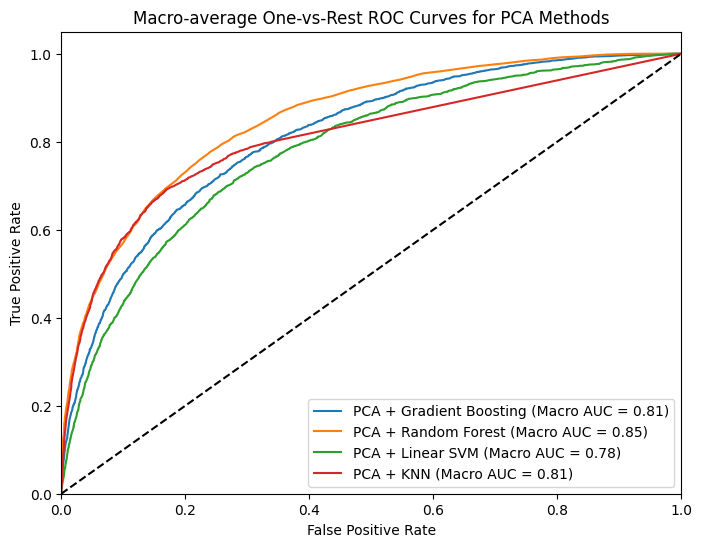

In [65]:
plt.figure(figsize=(8, 6))

# Loop through each PCA model's ROC curve data to compute and plot macro-average
for model_name, roc_data in roc_curves_pca.items():
    fpr = roc_data['fpr']
    tpr = roc_data['tpr']
    roc_auc = roc_data['roc_auc']

    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)

    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr,
             label=f"{model_name} (Macro AUC = {macro_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-average One-vs-Rest ROC Curves for PCA Methods")
plt.legend(loc="lower right")

plt.show()

### iv. Drawing the micro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods

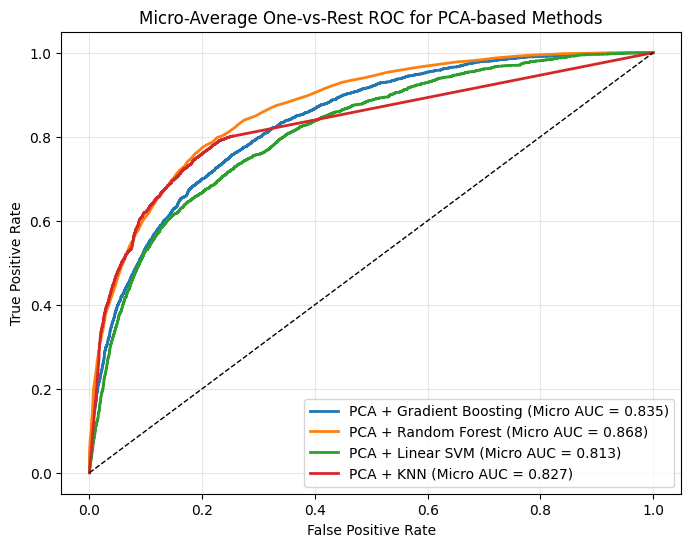

In [68]:
plt.figure(figsize=(8,6))

for model_name, y_proba in model_probs_pca.items():

    # Compute ROC curve points (needed for plotting)
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_bin.ravel(),
        y_proba.ravel()
    )

    # Retrieve previously computed Micro AUC
    micro = roc_auc_score(y_test_bin, y_proba, average='micro')

    # Plot micro-average ROC curve
    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"{model_name} (Micro AUC = {micro:.3f})",
        linewidth=2
    )

plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average One-vs-Rest ROC for PCA-based Methods")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

### v. For each class, drawing the One-vs-Rest ROCs for all classification methods into a separate graph, to allow for easy comparison between methods

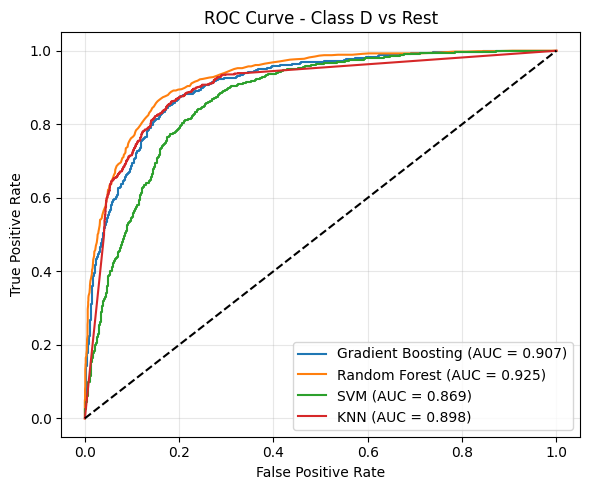

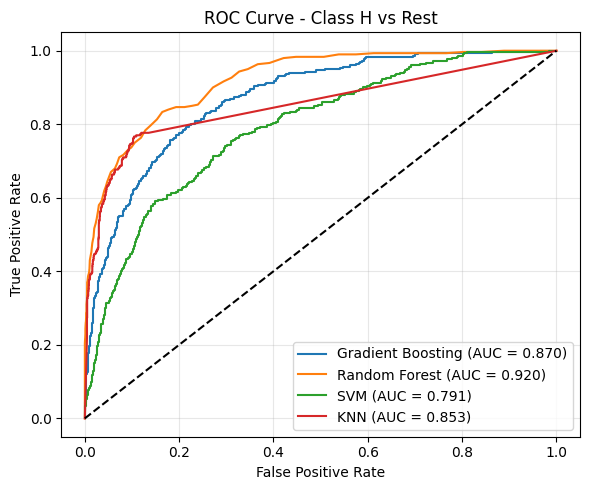

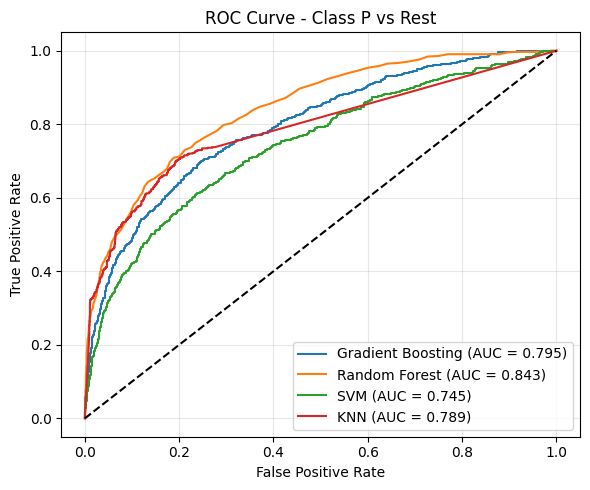

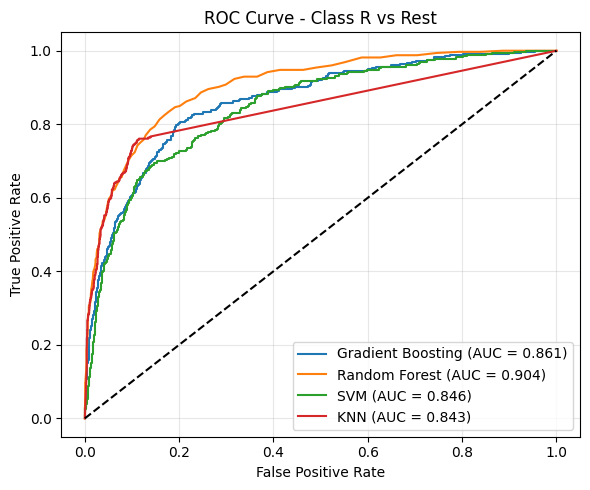

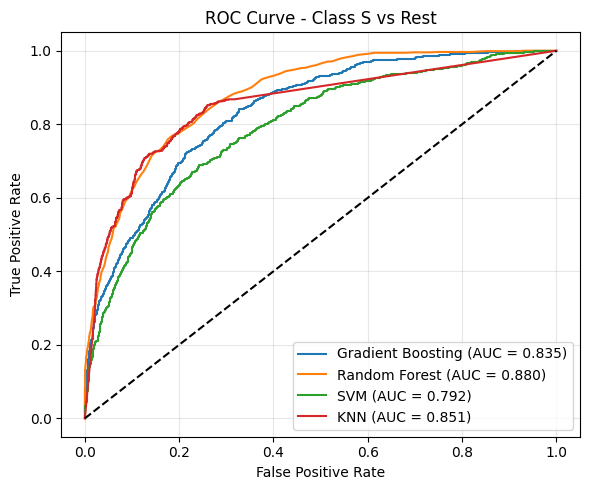

In [69]:
for i, class_name in enumerate(classes):

  plt.figure(figsize=(6,5))

  # loop through methods
  for model_name, y_proba in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

  plt.plot([0,1], [0,1], 'k--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title(f"ROC Curve - Class {class_name} vs Rest")

  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

### vi. Drawing all relevant confusion matrices

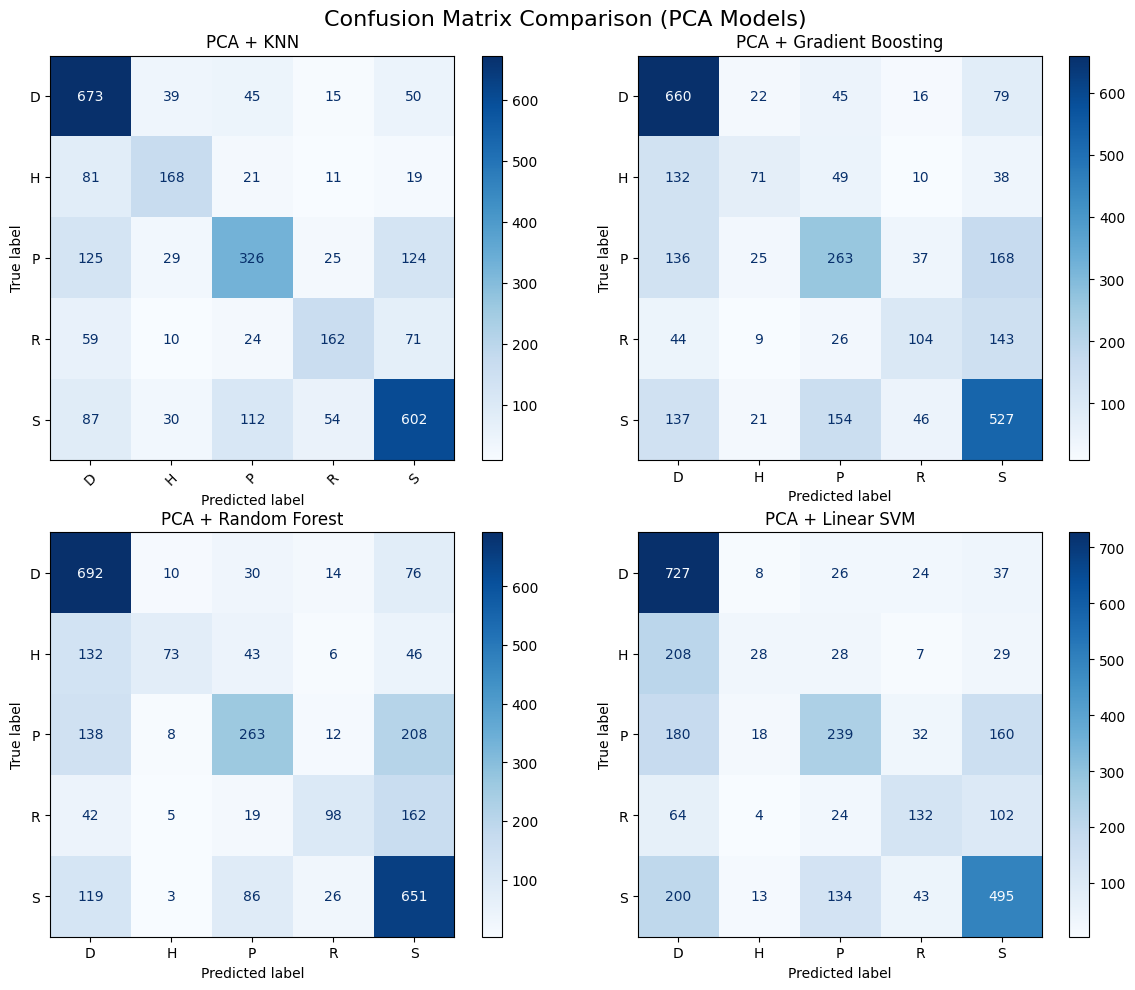

In [81]:
# Compute confusion matrices
cm_knn_pca = confusion_matrix(y_test, y_pred_pca_knn, labels=class_names)
cm_gb_pca = confusion_matrix(y_test, y_pred_gb_pca, labels=class_names)
cm_rf_pca = confusion_matrix(y_test, y_pred_rf_pca, labels=class_names)
cm_svm_pca = confusion_matrix(y_test, y_pred_svm_pca, labels=class_names)

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# PCA + KNN
disp_knn = ConfusionMatrixDisplay(cm_knn_pca, display_labels=class_names)
disp_knn.plot(ax=axes[0,0], cmap="Blues", values_format="d", xticks_rotation=45)
axes[0,0].set_title("PCA + KNN")

# PCA + Gradient Boosting
disp_gb = ConfusionMatrixDisplay(cm_gb_pca, display_labels=classes)
disp_gb.plot(ax=axes[0,1], cmap="Blues", values_format="d")
axes[0,1].set_title("PCA + Gradient Boosting")

# PCA + Random Forest
disp_rf = ConfusionMatrixDisplay(cm_rf_pca, display_labels=classes)
disp_rf.plot(ax=axes[1,0], cmap="Blues", values_format="d")
axes[1,0].set_title("PCA + Random Forest")

# PCA + Linear SVM
disp_svm = ConfusionMatrixDisplay(cm_svm_pca, display_labels=classes)
disp_svm.plot(ax=axes[1,1], cmap="Blues", values_format="d")
axes[1,1].set_title("PCA + Linear SVM")
fig.suptitle("Confusion Matrix Comparison (PCA Models)", fontsize=16)
plt.tight_layout()
plt.show()

# References (Harvard style referencing)
List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).

``References``
1. Murel, J. and Kavlakoglu, E. (n.d.) What is dimensionality reduction? Available at: https://www.ibm.com/think/topics/dimensionality-reduction

2. scikit-learn developers (2025) sklearn.ensemble.GradientBoostingClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

3. scikit-learn developers (2025) sklearn.neighbors.KNeighborsClassifier, sklearn.ensemble.RandomForestClassifier, sklearn.svm.SVC, and sklearn.metrics modules (including balanced_accuracy_score, roc_auc_score with one-vs-rest, and ConfusionMatrixDisplay). scikit-learn documentation. Available at: https://scikit-learn.org/stable/. (Implementation reference for all classification pipelines, hyperparameter tuning with GridSearchCV, StandardScaler, PCA, and evaluation metrics used in the notebook)

4. Madeo, R.C.B., Lima, C.A.M. and Peres, S.M. (2013) ‘Gesture unit segmentation using support vector machines: segmenting gestures from rest positions’, in Proceedings of the 28th Annual ACM Symposium on Applied Computing (SAC ’13). Coimbra, Portugal: ACM, pp. 46–52. Available at: https://doi.org/10.1145/2480362.2480373. (Original source for the GesturePhaseSegmentationProcessed dataset, OpenML ID 4538).